# **Q2: Which counties have childcare costs that are unusually high relative to peers with similar income levels, and are these anomalies persistent from 2008–2018 or concentrated in specific years?**

**1.Data importing & Instructure**(Use the code from Module 1)

In [1]:
import pandas as pd

CHILDCARE_URL = "https://raw.githubusercontent.com/paddington-L831/BA820-Unsupervised-and-Unstructured-Machine-Learning/refs/heads/main/childcare_costs.csv"
COUNTIES_URL = "https://raw.githubusercontent.com/paddington-L831/BA820-Unsupervised-and-Unstructured-Machine-Learning/refs/heads/main/counties.csv"

# Load datasets and merge
childcare = pd.read_csv(CHILDCARE_URL)
counties = pd.read_csv(COUNTIES_URL)

df = childcare.merge(counties, on="county_fips_code", how="left")

print("childcare shape:", childcare.shape)
print("counties shape:", counties.shape)
print("df shape:", df.shape)
print(df.dtypes)

df.head()

childcare shape: (34567, 61)
counties shape: (3144, 4)
df shape: (34567, 64)
county_fips_code        int64
study_year              int64
unr_16                float64
funr_16               float64
munr_16               float64
                       ...   
mfcc_toddler          float64
mfcc_preschool        float64
county_name            object
state_name             object
state_abbreviation     object
Length: 64, dtype: object


,county_fips_code,study_year,unr_16,funr_16,munr_16,unr_20to64,funr_20to64,munr_20to64,flfpr_20to64,flfpr_20to64_under6,...,mfccsa,mc_infant,mc_toddler,mc_preschool,mfcc_infant,mfcc_toddler,mfcc_preschool,county_name,state_name,state_abbreviation
0,1001,2008,5.42,4.41,6.32,4.6,3.5,5.6,68.9,66.9,...,81.40,104.95,104.95,85.92,83.45,83.45,81.40,Autauga County,Alabama,AL
1,1001,2009,5.93,5.72,6.11,4.8,4.6,5.0,70.8,63.7,...,85.68,105.11,105.11,87.59,87.39,87.39,85.68,Autauga County,Alabama,AL
2,1001,2010,6.21,5.57,6.78,5.1,4.6,5.6,71.3,67.0,...,89.96,105.28,105.28,89.26,91.33,91.33,89.96,Autauga County,Alabama,AL
3,1001,2011,7.55,8.13,7.03,6.2,6.3,6.1,70.2,66.5,...,94.25,105.45,105.45,90.93,95.28,95.28,94.25,Autauga County,Alabama,AL
4,1001,2012,8.60,8.88,8.29,6.7,6.4,7.0,70.6,67.1,...,98.53,105.61,105.61,92.60,99.22,99.22,98.53,Autauga County,Alabama,AL


In [2]:
df["study_year"].agg(["min", "max", "nunique"]), df["county_fips_code"].nunique()

(min        2008
 max        2018
 nunique      11
 Name: study_year, dtype: int64,
 3144)

In [3]:
missing_rate = df.isna().mean().sort_values(ascending=False)
missing_rate.head(10)

,0
mfccsa,0.323546
mfcc_preschool,0.323546
mfcc_infant,0.323546
mfcc_toddler,0.323546
mc_preschool,0.317470
mcsa,0.317470
mc_infant,0.317470
mc_toddler,0.317470
h_6to17_single_m,0.000058
h_under6_single_m,0.000058


In [4]:
missing_by_year = (
    childcare.groupby("study_year")["mc_infant"]
      .apply(lambda s: s.isna().mean() * 100)
      .round(2)
)

missing_by_year

,mc_infant
study_year,
2008,54.68
2009,39.52
2010,36.65
2011,36.62
2012,34.68
2013,34.01
2014,26.07
2015,23.68
2016,15.95


In [5]:
df[["mc_infant", "mfcc_infant", "mhi_2018", "pr_p"]].describe()

,mc_infant,mfcc_infant,mhi_2018,pr_p
count,23593.000000,23383.000000,34567.000000,34567.000000
mean,146.051770,113.421657,50446.777363,16.038131
std,53.698566,32.819372,13279.833788,6.511816
min,27.730000,43.080000,19841.920000,0.000000
25%,108.750000,90.000000,41839.215000,11.400000
50%,134.500000,106.000000,48505.600000,15.200000
75%,166.330000,129.315000,56201.450000,19.500000
max,470.000000,430.940000,136268.000000,55.100000


In [6]:
# merge on county_fips_code; use a left join to keep all cost records
df = childcare.merge(counties, on="county_fips_code", how="left")

# Check whether any county names are missing
missing_county_name_rate = df["county_name"].isna().mean()
print("Merged shape:", df.shape)
print("County name missing rate:", missing_county_name_rate)
print(df.head(10))

Merged shape: (34567, 64)
County name missing rate: 0.0
   county_fips_code  study_year  unr_16  funr_16  munr_16  unr_20to64  \
0              1001        2008    5.42     4.41     6.32         4.6   
1              1001        2009    5.93     5.72     6.11         4.8   
2              1001        2010    6.21     5.57     6.78         5.1   
3              1001        2011    7.55     8.13     7.03         6.2   
4              1001        2012    8.60     8.88     8.29         6.7   
5              1001        2013    9.39    10.31     8.56         7.3   
6              1001        2014    8.50     9.18     7.95         6.8   
7              1001        2015    7.64     8.45     6.91         5.9   
8              1001        2016    5.59     6.27     4.99         4.4   
9              1001        2017    5.21     5.84     4.64         4.6   

   funr_20to64  munr_20to64  flfpr_20to64  flfpr_20to64_under6  ...  mfccsa  \
0          3.5          5.6          68.9                 66.

**2.Refined Problem Statement & Focus**


In this stage, I examine which U.S. counties have childcare costs that are unusually high compared with counties at similar income levels. I also test whether these high cost counties remain consistently expensive across years or appear as temporary spikes in only a few years. I use county year observations from 2008 to 2018 and treat the median center based infant childcare cost mc_infant as the main cost outcome. To define comparable peers, I group counties by median household income mhi_2018 and model the expected relationship between income and childcare cost. Counties with large positive residuals from this learned baseline are labeled as high cost anomalies, because their observed costs are substantially above what the model predicts given income. As a robustness check, I optionally include additional socioeconomic features such as the poverty rate pr_p and the unemployment rate unr_20to64 to confirm that the anomaly patterns are not driven by omitted covariates.


In Module 1, our EDA mainly described overall patterns in the data. Childcare costs generally increase with income, but the cost and income relationship still shows substantial dispersion. In Module 2, I shift from description to a decision relevant anomaly framework. Instead of judging whether costs are high in absolute terms, I evaluate whether a county is high cost relative to other counties with similar income. This change is motivated by the idea that a strong average cost income association can still hide systematic mismatch counties that remain expensive even after controlling for local economic conditions.

At first, I expected most high childcare cost counties to simply be the highest income counties. However, the spread in the data shows that absolute cost and unexpectedly high cost given income are not the same. This motivates an income adjusted analysis that focuses on counties whose costs are higher than the model would predict for their income level. I also treat persistence as a data driven question. Some anomalies may reflect stable structural conditions that remain consistent across years, while others may be driven by short term shocks that appear only in certain years. To separate these patterns, I compute an income adjusted anomaly score using model residuals and then evaluate how consistently each county shows elevated residuals over time using a temporal persistence measure.

**3.EDA & Preprocessing: Updates**

Use a baseline model, either linear or log linear, to learn and predict the typical relationship between mc_infant and mhi_2018.

The residual is defined as the observed value minus the predicted value.

A larger residual indicates that, relative to counties with similar income levels, the county has unusually high childcare costs.

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# First run a 2018 cross-sectional sanity check (cleaner baseline)
d2018 = df[df["study_year"] == 2018].copy()

# Core variables: cost + income (optionally add more controls for robustness)
use_cols = ["mc_infant", "mhi_2018"]
d2018 = d2018.dropna(subset=use_cols)

# Log transform for stability (income and cost are typically right-skewed)
X = np.log1p(d2018[["mhi_2018"]].values)
y = np.log1p(d2018["mc_infant"].values)

lr = LinearRegression().fit(X, y)
pred = lr.predict(X)

# Residuals in log space
d2018["residual_log"] = y - pred

# Use to inspect residual distribution / identify top outliers
d2018[["residual_log"]].describe()

,residual_log
count,2.360000e+03
mean,-1.190761e-15
std,2.522890e-01
min,-1.566676e+00
25%,-1.488919e-01
50%,1.698625e-02
75%,1.574488e-01
max,1.187929e+00


To evaluate whether a county is persistently high cost, I first need to measure data availability for each county. Specifically, I count how many years have enough information to compute a residual, meaning both the childcare cost and the income variable are observed. I then set a minimum coverage threshold, for example at least six years, before calculating persistence metrics. This ensures that persistence is estimated only for counties with sufficient time series coverage and reduces noise from sparse observations.

In [9]:
# Construct residuals over the full period (log cost ~ log income).
# A year-by-year fit is more rigorous, but this is a simplified pooled version.
d_all = df.dropna(subset=["mc_infant", "mhi_2018", "study_year"]).copy()

X_all = np.log1p(d_all[["mhi_2018"]].values)
y_all = np.log1p(d_all["mc_infant"].values)

lr_all = LinearRegression().fit(X_all, y_all)
d_all["residual_log"] = y_all - lr_all.predict(X_all)

# Number of available years per county (years where residual can be computed)
years_available = d_all.groupby("county_fips_code")["study_year"].nunique()

# Coverage threshold: at least 6 years (you can change to 5/7/8)
eligible = years_available[years_available >= 6].index
d_all_elig = d_all[d_all["county_fips_code"].isin(eligible)].copy()

print("Eligible counties:", d_all_elig["county_fips_code"].nunique())

Eligible counties: 2074


In [10]:
# years_available = 8
# Construct residuals over the full period (log cost ~ log income).
# A year-by-year fit is more rigorous, but this is a simplified pooled version.
d_all = df.dropna(subset=["mc_infant", "mhi_2018", "study_year"]).copy()

X_all = np.log1p(d_all[["mhi_2018"]].values)
y_all = np.log1p(d_all["mc_infant"].values)

lr_all = LinearRegression().fit(X_all, y_all)
d_all["residual_log"] = y_all - lr_all.predict(X_all)

# Number of available years per county (years where residual can be computed)
years_available = d_all.groupby("county_fips_code")["study_year"].nunique()

# Coverage threshold: at least 6 years (you can change to 5/7/8)
eligible = years_available[years_available >= 8].index
d_all_elig = d_all[d_all["county_fips_code"].isin(eligible)].copy()

print("Eligible counties:", d_all_elig["county_fips_code"].nunique())

Eligible counties: 1987


I set a minimum coverage threshold to ensure persistence is computed only for counties with sufficient time series information. A higher threshold such as at least 7 or 8 years yields more stable persistence estimates but reduces the eligible sample size, while a lower threshold such as at least 6 years increases coverage at the cost of noisier persistence classification. This issue is part of the current milestone, and I have not yet decided which coverage threshold to use.

After completing this step, I realized that heavy missingness in the early years can introduce systematic bias in anomaly detection. First, if only a subset of counties has available data, the observed sample may not be missing at random, and certain types of counties may be overrepresented. This can make comparisons among similar income peers less reliable and can affect how the baseline relationship is learned. Second, if a county is missing in the early years but appears in later years with consistently high residuals, the incomplete time series may lead to an incorrect classification as a short term spike or a persistent anomaly. Conversely, if a county is observed in only a few years, limited information may cause it to be incorrectly labeled as anomalous or non anomalous.

This robustness check was not implemented in the current milestone. In the next stage, I plan to restrict the analysis to a higher coverage time window and recompute the income adjusted anomaly score and persistence metrics to evaluate whether the conclusions remain stable under different missingness patterns.

**3-1. Top residual counties / Persistent counties**

In [29]:
d_all = df.dropna(subset=["study_year", "mc_infant", "mhi_2018", "county_fips_code"]).copy()
X = np.log1p(d_all[["mhi_2018"]].values)
y = np.log1p(d_all["mc_infant"].values)

lr = LinearRegression().fit(X, y)
d_all["residual_log"] = y - lr.predict(X)
# === top-X% flag ===
TOP_PCT = 0.05
thr = d_all["residual_log"].quantile(1 - TOP_PCT)
d_all["is_top"] = (d_all["residual_log"] >= thr).astype(int)

# === B1 persistence by county ===
county_persist = (
    d_all.groupby("county_fips_code")
        .agg(
            years_available=("study_year", "nunique"),
            years_top=("is_top", "sum"),
            persistence=("is_top", "mean")
        )
        .reset_index()
)
def bucket(p):
    if p == 0:
        return "Never high"
    elif p >= 0.30:
        return "Persistent"
    else:
        return "Occasional spikes"

county_persist["pattern_B1"] = county_persist["persistence"].apply(bucket)

# add names
name_cols = ["county_fips_code"]
for col in ["county_name", "state_abbreviation", "state_name", "state"]:
    if col in df.columns:
        name_cols.append(col)
names = df[name_cols].drop_duplicates()
county_persist_named = county_persist.merge(names, on="county_fips_code", how="left")
# Persistent top 10
top_persistent = (
    county_persist_named[county_persist_named["pattern_B1"]=="Persistent"]
    .sort_values("persistence", ascending=False)
    .head(10)
    [["county_name","state_abbreviation","years_available","years_top","persistence","county_fips_code"]]
)

top_persistent

,county_name,state_abbreviation,years_available,years_top,persistence,county_fips_code
181,Humboldt County,CA,11,11,1.0,6023
173,Butte County,CA,11,11,1.0,6007
230,Arapahoe County,CO,1,1,1.0,8005
234,Boulder County,CO,1,1,1.0,8013
186,Lake County,CA,11,11,1.0,6033
192,Mendocino County,CA,11,11,1.0,6045
244,Denver County,CO,1,1,1.0,8031
247,Eagle County,CO,1,1,1.0,8037
249,El Paso County,CO,1,1,1.0,8041
251,Garfield County,CO,1,1,1.0,8045


**3-2. Where are the anomalous counties concentrated?**

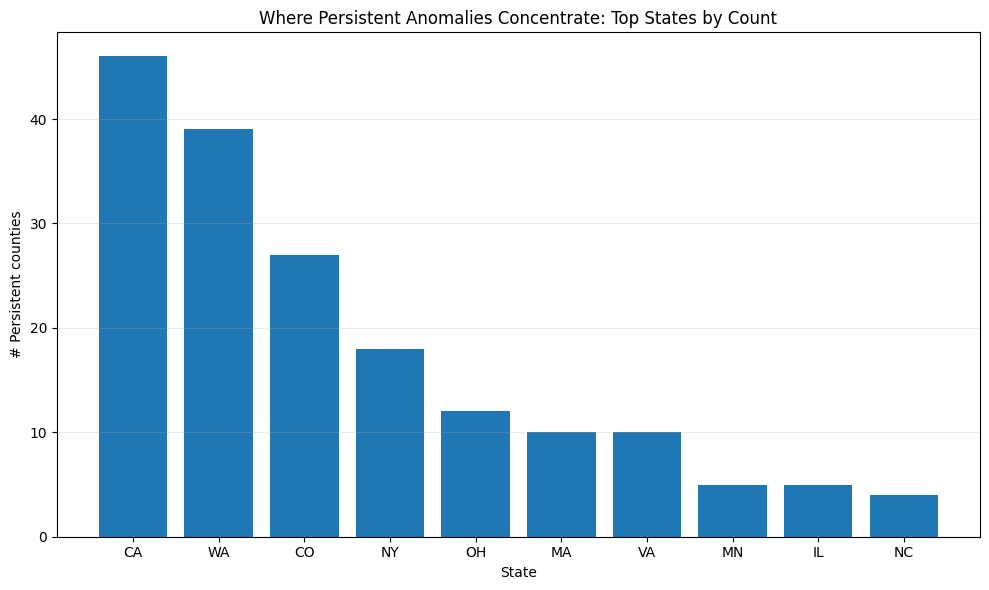

,count
state_abbreviation,
CA,46
WA,39
CO,27
NY,18
OH,12
MA,10
VA,10
MN,5
IL,5


In [30]:
state_col = "state_abbreviation" if "state_abbreviation" in county_persist_named.columns else "state"

persistent_df = county_persist_named[county_persist_named["pattern_B1"]=="Persistent"].copy()

state_counts = (
    persistent_df[state_col]
    .value_counts()
    .head(10)
)

# plot
plt.figure(figsize=(10,6))
plt.bar(state_counts.index, state_counts.values)
plt.title("Where Persistent Anomalies Concentrate: Top States by Count")
plt.xlabel("State")
plt.ylabel("# Persistent counties")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

state_counts

**3-3. Are high-residual (anomalous) counties persistent, or mostly occasional spikes?**

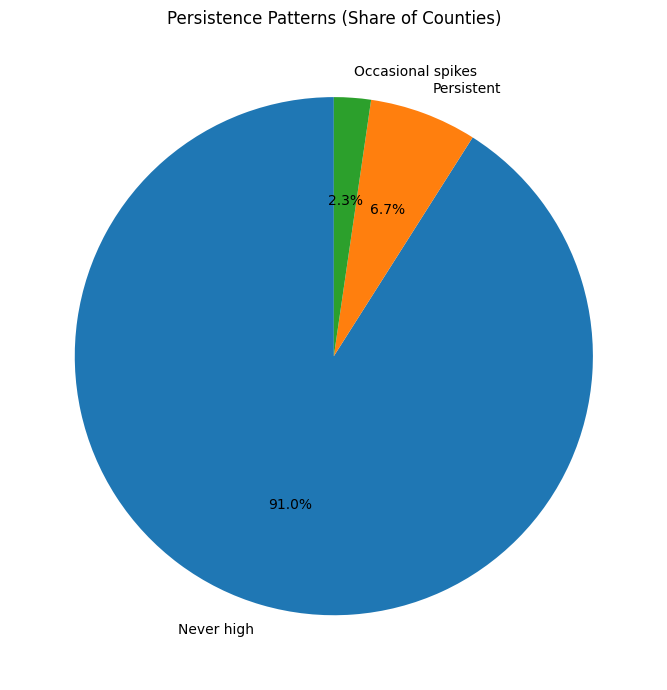

In [31]:
pattern_counts = county_persist["pattern_B1"].value_counts()
pattern_share = (pattern_counts / pattern_counts.sum()).round(3)

plt.figure(figsize=(7,7))
plt.pie(
    pattern_share.values,
    labels=pattern_share.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Persistence Patterns (Share of Counties)")
plt.tight_layout()
plt.show()

**3-4. In which years do spike patterns occur most frequently?**

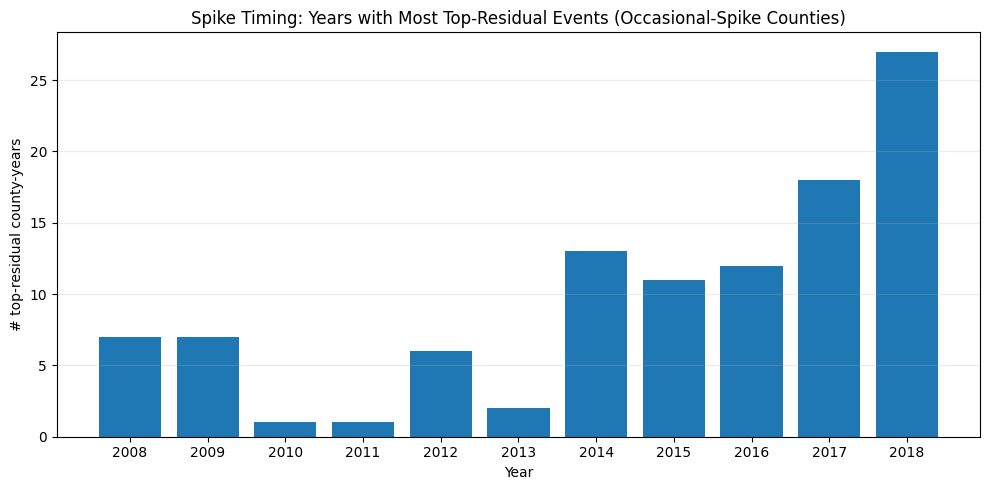

,count
study_year,
2008,7
2009,7
2010,1
2011,1
2012,6
2013,2
2014,13
2015,11
2016,12


In [32]:
spike_counties = county_persist[county_persist["pattern_B1"]=="Occasional spikes"]["county_fips_code"]

spike_events = d_all[
    (d_all["county_fips_code"].isin(spike_counties)) &
    (d_all["is_top"] == 1)
].copy()

year_spike_counts = spike_events["study_year"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.bar(year_spike_counts.index.astype(str), year_spike_counts.values)
plt.title("Spike Timing: Years with Most Top-Residual Events (Occasional-Spike Counties)")
plt.xlabel("Year")
plt.ylabel("# top-residual county-years")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

year_spike_counts

**4 Analysis & Experiments**

**4-1 Residual trajectory clustering**

In [11]:
# Pivot: one row per county, one column per year
mat = d_all.pivot_table(index="county_fips_code", columns="study_year", values="residual_log", aggfunc="mean")

# Require at least 8 non-missing years (you can change this)
min_years = 8
eligible_idx = mat.dropna(thresh=min_years).index
mat_elig = mat.loc[eligible_idx].copy()

# Imputation: fill missing values with the county mean (row mean)
row_mean = mat_elig.mean(axis=1)
mat_filled = mat_elig.T.fillna(row_mean).T

mat.shape, mat_elig.shape, mat_filled.isna().sum().sum()


((2904, 11), (1987, 11), np.int64(0))

The initial residual matrix includes 2,904 counties. After filtering out counties with insufficient coverage, 1,987 counties remain. Then, after imputing missing years using each county’s mean residual, there are no missing values left in the matrix.

**Standardization plus KMeans clustering**

Because the magnitude of residuals can vary substantially across counties, I experimented with different values of k.

To determine the most appropriate value of K, I used SSE and the Silhouette Score to guide model selection. In this milestone, I evaluated a range of K values and attempted to choose a final K based on these metrics as well as cluster interpretability.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

X_mat = mat_filled.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_mat)

k_list = range(2, 9)
rows = []

for k in k_list:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia = km.inertia_
    sil = silhouette_score(X_scaled, labels)
    rows.append({"K": k, "inertia": inertia, "silhouette": sil})

k_eval = pd.DataFrame(rows)
k_eval

,K,inertia,silhouette
0,2,10035.186163,0.442789
1,3,5718.775337,0.454056
2,4,4166.622798,0.375957
3,5,3378.167299,0.340016
4,6,3024.854933,0.303569
5,7,2757.716245,0.277834
6,8,2590.411072,0.240637


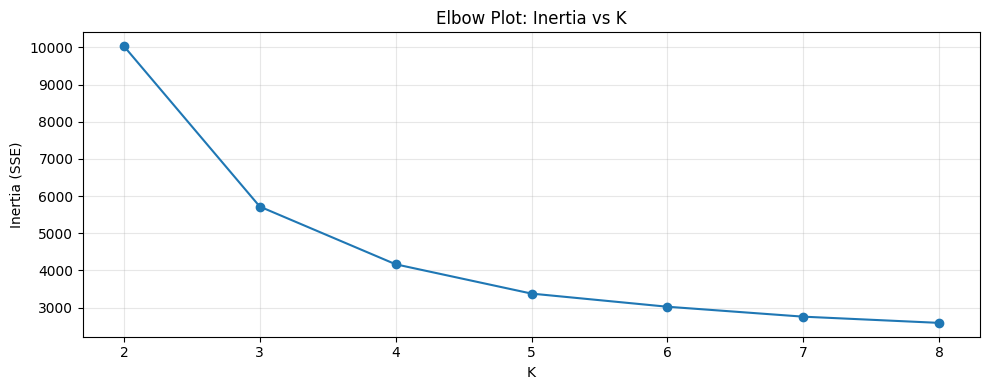

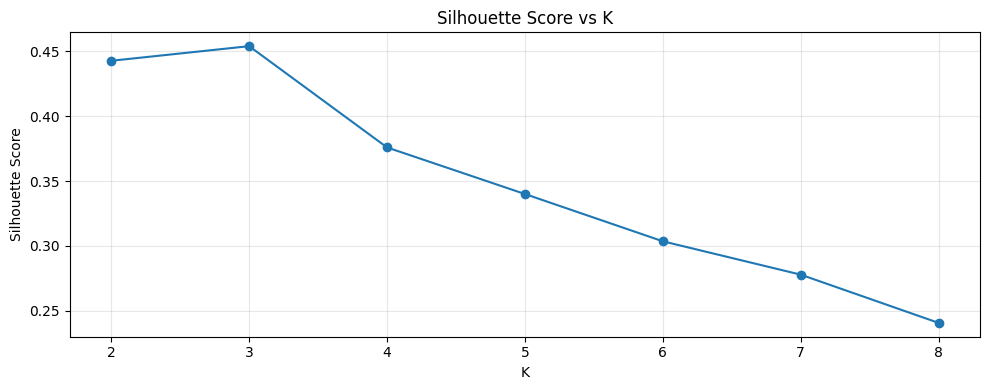

In [18]:
plt.figure(figsize=(10,4))
plt.plot(k_eval["K"], k_eval["inertia"], marker="o")
plt.title("Elbow Plot: Inertia vs K")
plt.xlabel("K")
plt.ylabel("Inertia (SSE)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(k_eval["K"], k_eval["silhouette"], marker="o")
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

As an interpretability check, we also compared the average cluster trajectories for K equals 3 and 4. If K equals 4 more clearly separates two distinct shapes, such as a late rise pattern versus a spike pattern, we will adopt K equals 4 as long as it does not substantially reduce clustering quality. Otherwise, we will use K equals 3 as a more parsimonious choice with the best overall metrics.

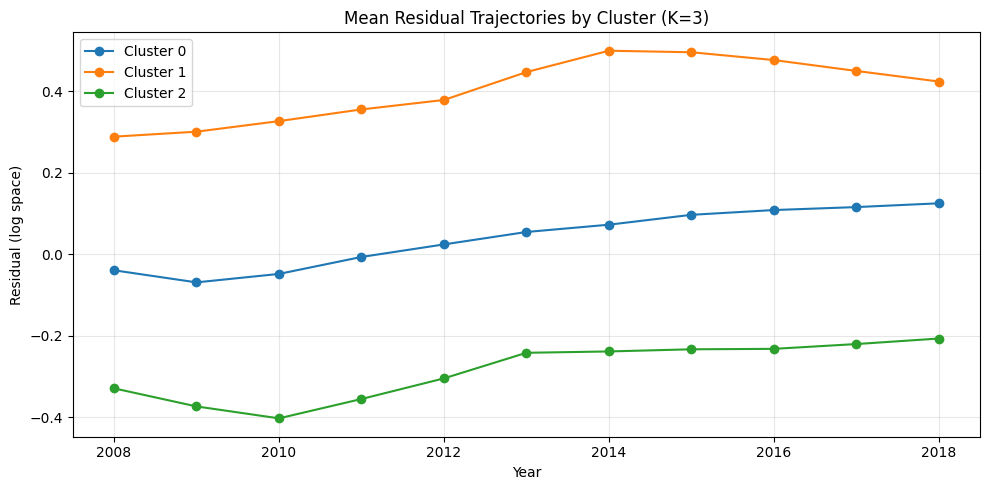

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X = mat_filled.values
X_scaled = StandardScaler().fit_transform(X)
K = 3
labels = KMeans(n_clusters=K, random_state=42, n_init=20).fit_predict(X_scaled)

tmp = mat_filled.copy()
tmp["cluster"] = labels
cluster_means = tmp.groupby("cluster").mean()

plt.figure(figsize=(10,5))
for c in cluster_means.index:
    plt.plot(cluster_means.columns, cluster_means.loc[c], marker="o", label=f"Cluster {c}")
plt.title(f"Mean Residual Trajectories by Cluster (K={K})")
plt.xlabel("Year")
plt.ylabel("Residual (log space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

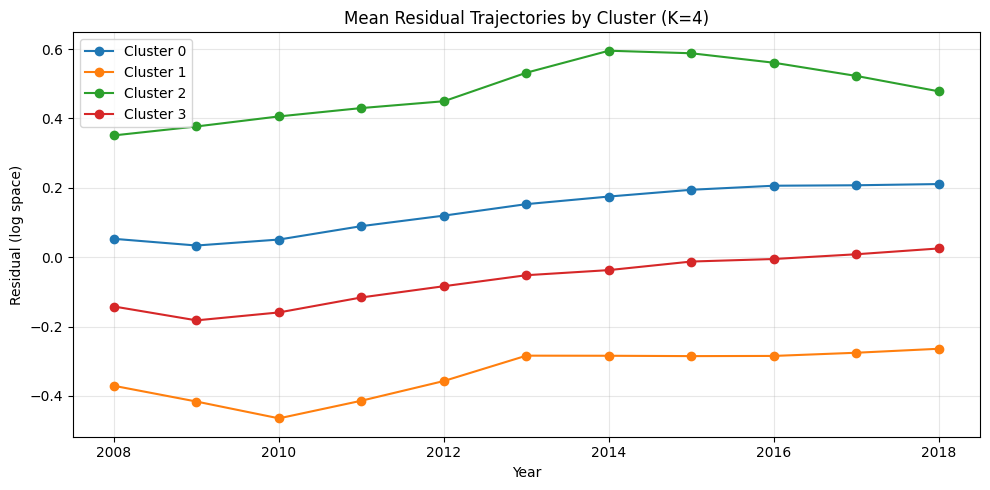

In [21]:

X = mat_filled.values
X_scaled = StandardScaler().fit_transform(X)
K = 4
labels = KMeans(n_clusters=K, random_state=42, n_init=20).fit_predict(X_scaled)

tmp = mat_filled.copy()
tmp["cluster"] = labels
cluster_means = tmp.groupby("cluster").mean()

plt.figure(figsize=(10,5))
for c in cluster_means.index:
    plt.plot(cluster_means.columns, cluster_means.loc[c], marker="o", label=f"Cluster {c}")
plt.title(f"Mean Residual Trajectories by Cluster (K={K})")
plt.xlabel("Year")
plt.ylabel("Residual (log space)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Although the silhouette score reaches its maximum at K equals 3, the mean trajectory visualizations suggest that K equals 3 primarily separates counties by overall residual magnitude into high, medium, and low groups. This setting tends to combine counties that have different temporal dynamics into the same cluster. Because the objective is to recover interpretable trajectory archetypes over time, K equals 4 yields a more informative partition by producing four clusters with clearly distinct residual patterns across years. Based on this tradeoff, I select K equals 4 as the final clustering solution, placing greater weight on interpretability that directly supports the research question rather than choosing the single highest silhouette score.





**4-2 Hierarchical Clustering**

numeric shape: (1987, 11)


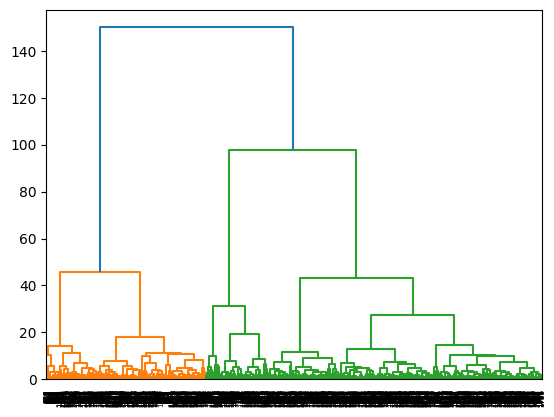

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster


mat_num = mat_filled.select_dtypes(include=[np.number]).copy()
print("numeric shape:", mat_num.shape)
X = mat_num.values
X_scaled = StandardScaler().fit_transform(X)

Z = linkage(X_scaled, method="ward")
_ = dendrogram(Z,)


   k  silhouette
0  2    0.449858
1  3    0.450940
2  4    0.377793
3  5    0.290824
4  6    0.289669
5  7    0.236312
6  8    0.231738


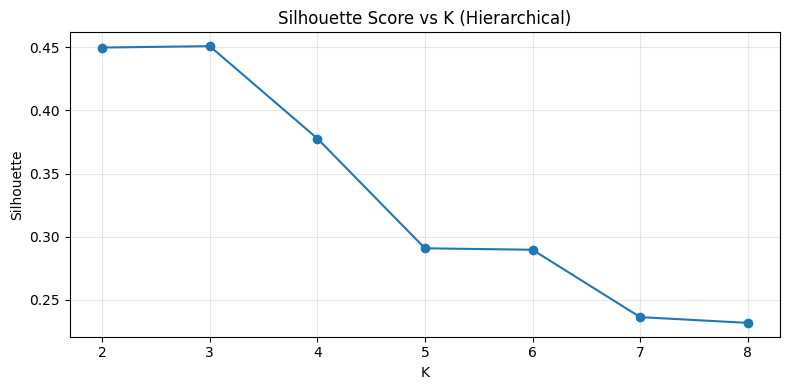

Best K by silhouette: 3


In [41]:
k_list = range(2, 9)
scores = []
for k in k_list:
    labels = fcluster(Z, k, criterion="maxclust")
    sil = silhouette_score(X_scaled, labels)
    scores.append({"k": k, "silhouette": sil})
k_eval = pd.DataFrame(scores)
print(k_eval)
plt.figure(figsize=(8,4))
plt.plot(k_eval["k"], k_eval["silhouette"], marker="o")
plt.title("Silhouette Score vs K (Hierarchical)")
plt.xlabel("K")
plt.ylabel("Silhouette")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
best_k = k_eval.loc[k_eval["silhouette"].idxmax(), "k"]
print("Best K by silhouette:", int(best_k))

In [53]:
cols_to_drop = [c for c in df.columns if c.startswith("cluster_labels")]
df = df.drop(columns=cols_to_drop, errors="ignore")

df = df.merge(traj_clusters_h, on="county_fips_code", how="left")
df['cluster_labels'].value_counts()

,count
cluster_labels,
3,12089
1,7062
2,2706


Based on the current results, the best value of K is not consistent across clustering methods. This suggests there is no single unique optimal split in the data. In our tests, KMeans supports both K equals 3 and K equals 4 as reasonable choices. Each option has tradeoffs in clustering metrics and in how easy the average trajectories are to interpret. In contrast, Ward hierarchical clustering points more strongly to K equals 3 under the same evaluation setup. This difference is expected because KMeans and hierarchical clustering use different objectives and make different assumptions about cluster structure. They can also respond differently to within cluster variance, cluster shapes, and borderline observations.

For this milestone, we do not treat K as a fixed value that is fully determined. Instead, we keep K equals 3 and K equals 4 as the main candidates. In the next stage, we will use additional evidence to decide. For example, we will check whether the mean trajectories under each K clearly separate persistent patterns from spike patterns. We will also test how sensitive the clustering is to standardization and missing value imputation. We will compare geographic concentration and case examples across clusters to see which solution is more consistent and easier to explain. Overall, we prioritize stable and interpretable trajectory archetypes that match the research goal rather than relying on a single metric to choose one K.

**5 Findings & Interpretations**


This section summarizes my main findings and why they matter in the real world. To keep the conclusions based on evidence, I use an income adjusted residual score to find counties where childcare costs look unusually high compared to other counties with similar income. Then I check whether these unusual cases stay high for many years or only show up as short spikes.

In EDA part, I focus on three questions. First, which counties are flagged as anomalies, and whether they are concentrated in a small number of states or regions. Second, how big the persistent group is compared to the spike group, and which years have the most spike events. Third, what these patterns might mean for policymakers and other stakeholders. In general, persistent anomalies are more likely to reflect long run structural problems, while spike anomalies are more likely to reflect short term shocks or data issues.

Where do anomaly counties concentrate? Using the income adjusted residual score, I identify counties whose childcare costs are higher than expected given their income level. The most policy relevant cases are counties that repeatedly fall into the top 5 percent of residuals over time, which I label as Persistent anomalies. In my results, these persistent anomalies are not spread evenly across the country. Instead, they are concentrated in a small set of states, such as California and Washington. This suggests the problem may be linked to state or local factors like supply constraints, regulations, or market structure, not just differences in income.

Are anomalies structural or episodic? I group counties into three patterns: Persistent, Occasional spikes, and Never high. Persistent counties make up about 6.7% of counties with enough data, while Occasional spikes make up about 2.3%. This shows that many “high residual” events are not permanent and may happen only in a few years. When I look only at the spike group, the top residual events appear more often in certain years, such as 2018. This suggests spikes may be tied to specific time periods rather than happening steadily from 2008 to 2018.

What does this mean for decisions? Persistent high residual counties are likely places with structural barriers, such as long term childcare supply shortages, limited competition, or ongoing capacity constraints. These counties may need longer term solutions, such as expanding supply, adjusting regulations, or targeting sustained support. In contrast, spike only counties may reflect temporary disruptions, short term demand changes, or data coverage noise. For these places, the better approach is often short term monitoring and validation instead of major policy changes. Overall, separating persistent anomalies from spikes helps prioritize attention. Persistent counties point to where long run action is most needed, while spike counties point to where quick checks and short term support may be more appropriate.

**6) Next Steps**

Building on Moudle 2, I have identified counties with childcare costs that are unusually high relative to income similar peers using an income adjusted residual score. I then separated these counties into interpretable time patterns using two approaches, a persistence based rule set and trajectory clustering with KMeans using K equals 4. The next phase will focus on improving both robustness and interpretability.

First, I will run robustness checks to confirm that the anomaly and persistence results are not driven by modeling choices. I will estimate residuals using year specific regressions rather than a single pooled model, and I will expand the baseline model by adding basic socioeconomic controls such as poverty and unemployment. I will also test sensitivity to key design choices, including the residual cutoff used to define anomalies and the minimum year coverage threshold used for persistence.

Second, in the next stage, I will add robustness checks and further refine the choice of K. I will test whether the clustering results remain stable under alternative preprocessing decisions, such as different standardization methods and missing value imputation strategies, and under different anomaly definitions and coverage thresholds. I will also compare K equals 3 and K equals 4 using multiple criteria, including silhouette scores, cluster size balance, and the interpretability of the mean residual trajectories. These checks will help ensure that the selected K produces stable and meaningful trajectory patterns that align with the research objective.

Finally, I will link anomaly persistence to decision relevant outcomes to better motivate the analysis in the final report. For example, I will examine whether persistent high residual counties are associated with lower female labor force participation among households with young children and whether counties are more similar within states than across states. This will help assess whether persistent anomalies align with broader economic constraints and will support more targeted policy or market level recommendations.
